In [25]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb


data = pd.read_csv('datos_caso_2.csv')
data

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.000,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.000,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.000,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.0,0.000,0.000,0.007,0.000,0.0,0.0,79.0,0.2,25.0,...,137.0,177.0,4.0,0.0,153.0,150.0,152.0,2.0,0.0,2.0
2122,140.0,0.001,0.000,0.007,0.000,0.0,0.0,78.0,0.4,22.0,...,103.0,169.0,6.0,0.0,152.0,148.0,151.0,3.0,1.0,2.0
2123,140.0,0.001,0.000,0.007,0.000,0.0,0.0,79.0,0.4,20.0,...,103.0,170.0,5.0,0.0,153.0,148.0,152.0,4.0,1.0,2.0
2124,140.0,0.001,0.000,0.006,0.000,0.0,0.0,78.0,0.4,27.0,...,103.0,169.0,6.0,0.0,152.0,147.0,151.0,4.0,1.0,2.0


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

Como se puede observar no hay datos nill ni hay variables categóricas

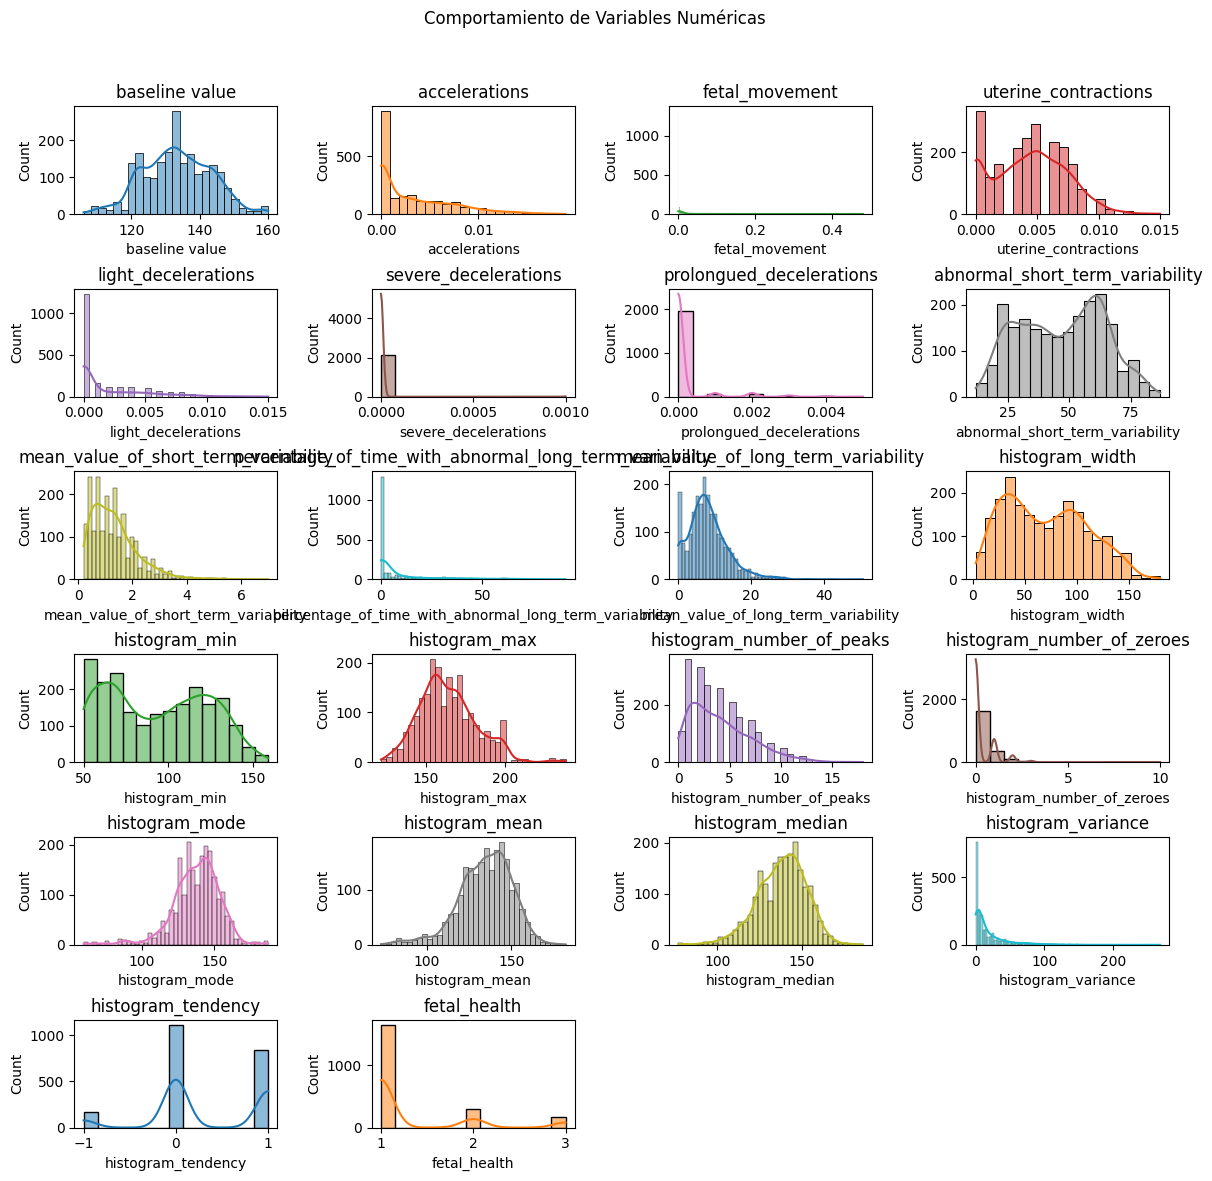

In [27]:


num_col = data.select_dtypes(include=['int64', 'float64']).columns
fig, ax = plt.subplots(
    nrows=(len(num_col) // 4) + (1 if len(num_col) % 4 != 0 else 0),
    ncols=4,
    figsize=(12, 12)
)
ax = ax.flat

for i, col in enumerate(num_col):
    sb.histplot(
        data=data,  
        x=col,
        kde=True,
        color=(list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'],
        ax=ax[i]
    )
    ax[i].set_title(col)

# Ocultar ejes vacíos
for j in range(len(num_col), len(ax)):
    ax[j].set_visible(False)

fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()



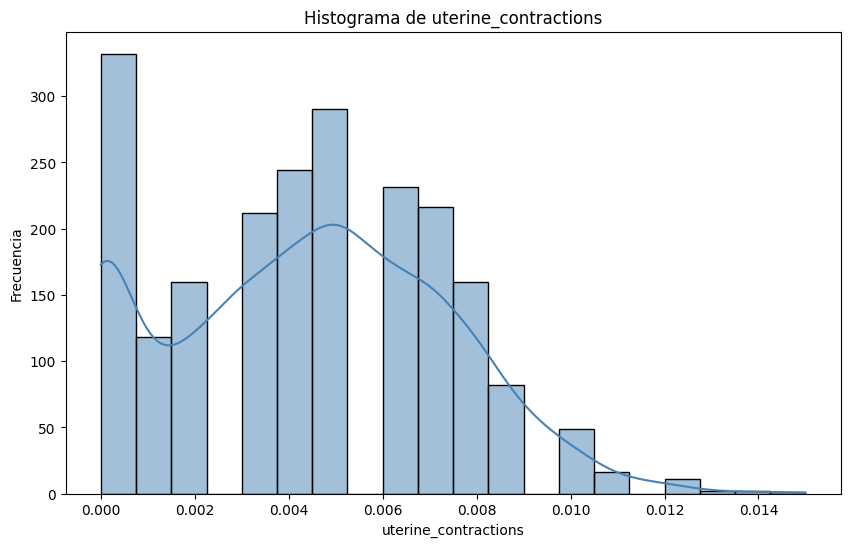

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sb

columna = "uterine_contractions"

plt.figure(figsize=(8, 6))
sb.histplot(
    data=data,
    x=columna,
    kde=True,
    color="steelblue"
)

# Cambiar la escala (ejemplo: mostrar solo de 0 a 50 en el eje X)
plt.xlim(0, 50)   # límites en el eje X
plt.ylim(0, 100)  # límites en el eje Y (frecuencia)

plt.title(f"Histograma de {columna}")
plt.xlabel(columna)
plt.ylabel("Frecuencia")
plt.show()


In [ ]:
data.columns

Index(['baseline value', 'accelerations', 'fetal_movement',
       'uterine_contractions', 'light_decelerations', 'severe_decelerations',
       'prolongued_decelerations', 'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'mean_value_of_long_term_variability', 'histogram_width',
       'histogram_min', 'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean',
       'histogram_median', 'histogram_variance', 'histogram_tendency',
       'fetal_health'],
      dtype='object')

<Axes: title={'center': 'Distribución de Deceleraciones Severas'}, ylabel='count'>

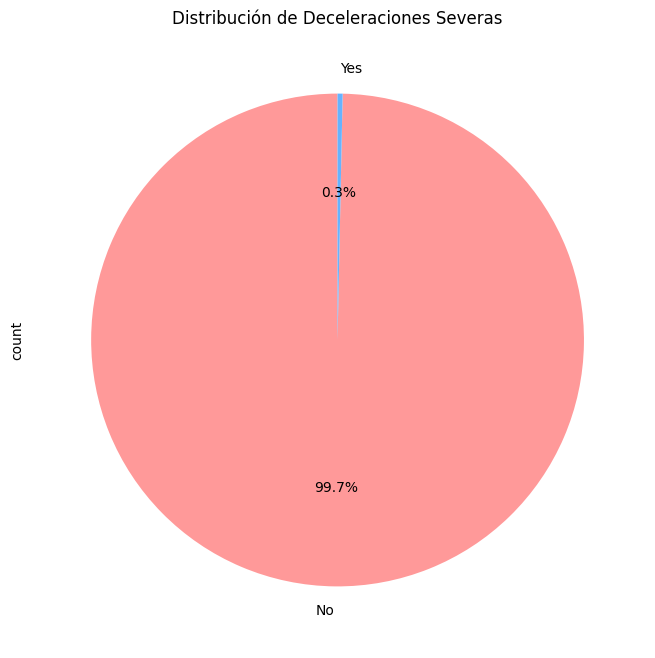

In [ ]:
data['severe_decelerations'].describe()


# Hacer grafico de torta para severe_decelerations
severe_counts = data['severe_decelerations'].value_counts() 
severe_counts.plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff9999', '#66b3ff'],
    labels=['No', 'Yes'],
    title='Distribución de Deceleraciones Severas',
    figsize=(8, 8)
)

In [ ]:
data_mod = data.drop(columns=['severe_decelerations','prolongued_decelerations'])

In [ ]:
X=data_mod.drop(columns=['fetal_health'])

Y=data_mod['fetal_health']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline

# Columnas numéricas
num_cols = X.select_dtypes(include=['float64']).columns.to_list()

# Pipeline
num_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])


# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
], remainder='passthrough')




In [ ]:
# 1. Aplicar el preprocesamiento
X_pre = preprocessor.fit_transform(X)

# 2. Reconstruir el DataFrame con los nombres de columna originales
X_pro = pd.DataFrame(X_pre, columns=X.columns, index=X.index)

# 3. Revisar el resultado
X_pro.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency
0,0.259259,0.000000,0.0,0.000000,0.0,0.813333,0.044118,0.472527,0.047337,0.344633,0.110092,0.034483,0.111111,0.0,0.472441,0.587156,0.403670,0.271375,1.0
1,0.481481,0.315789,0.0,0.400000,0.2,0.066667,0.279412,0.000000,0.205128,0.717514,0.165138,0.655172,0.333333,0.1,0.637795,0.577982,0.577982,0.044610,0.5
2,0.500000,0.157895,0.0,0.533333,0.2,0.053333,0.279412,0.000000,0.264300,0.717514,0.165138,0.655172,0.277778,0.1,0.637795,0.568807,0.559633,0.048327,0.5
3,0.518519,0.157895,0.0,0.533333,0.2,0.053333,0.323529,0.000000,0.453649,0.644068,0.027523,0.413793,0.611111,0.0,0.606299,0.559633,0.550459,0.048327,1.0
4,0.481481,0.368421,0.0,0.533333,0.0,0.053333,0.323529,0.000000,0.392505,0.644068,0.027523,0.413793,0.500000,0.0,0.606299,0.577982,0.559633,0.040892,1.0


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_pro, Y, test_size=0.7, random_state=123)   

print(f'El tamaño del conjunto de entrenamiento es: {X_train.shape} {Y_train.shape} \n'
      f'El tamaño del conjunto de prueba es: {X_test.shape} {Y_test.shape} \n') 


El tamaño del conjunto de entrenamiento es: (637, 19) (637,) 
El tamaño del conjunto de prueba es: (1489, 19) (1489,) 



Distribución de las clases en el conjunto de entrenamiento

([<matplotlib.patches.Wedge at 0x2573fb11340>,
 [Text(-0.8375906060184473, 0.7130511739767704, '1.0'),
  Text(0.6203990884720896, -0.9083528890376255, '2.0'),
  Text(1.0612205184000134, -0.28950131489650793, '3.0')],
 [Text(-0.4568676032827893, 0.3889370039873293, '77.6%'),
  Text(0.3383995028029579, -0.4954652122023411, '14.0%'),
  Text(0.5788475554909164, -0.15790980812536795, '8.5%')])

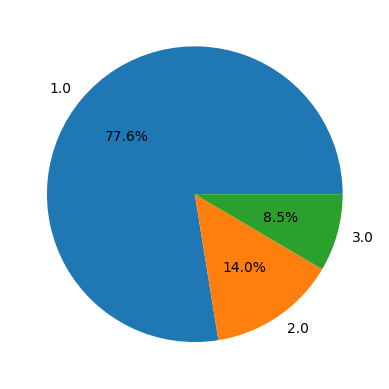

In [ ]:
plt.pie(x=Y_train.value_counts(),
        labels=Y_train.value_counts().index,
        autopct='%0.1f%%')



Distribucion de las clases en el conjunto de prueba

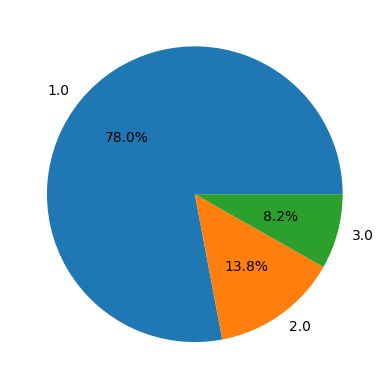

In [ ]:
plt.pie(
    x=Y_test.value_counts(),
    labels=Y_test.value_counts().index,
    autopct='%0.1f%%'
)
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
modelo_1 = LogisticRegression(solver='saga', random_state=123)
param_grid={'penalty': ['l1', 'l2', 'elasticnet'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

clf_1= GridSearchCV(estimator=modelo_1,
                   param_grid=param_grid, cv=5, scoring='accuracy')


clf_1.fit(X_train, Y_train)




,estimator,LogisticRegre...solver='saga')
,param_grid,"{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [ ]:
validation = pd.concat([
    pd.DataFrame(clf_1.cv_results_['params']),
    pd.DataFrame(clf_1.cv_results_['mean_test_score'], columns=['accuracy'])
], axis=1)

validation = validation.sort_values(by='accuracy', ascending=False)



validation

,C,penalty,accuracy
13,10.000,l2,0.883846
12,10.000,l1,0.882308
16,100.000,l2,0.882308
15,100.000,l1,0.880733
19,1000.000,l2,0.880733
18,1000.000,l1,0.880733
9,1.000,l1,0.879122
10,1.000,l2,0.875935
7,0.100,l2,0.795940
6,0.100,l1,0.778666


In [ ]:
modelo_1_final = clf_1.best_estimator_
modelo_1_final


,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,123
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


metricas de desempeño en entrenamiento
              precision    recall  f1-score   support

         1.0       0.94      0.96      0.95       494
         2.0       0.70      0.66      0.68        89
         3.0       0.85      0.74      0.79        54

    accuracy                           0.90       637
   macro avg       0.83      0.79      0.81       637
weighted avg       0.90      0.90      0.90       637



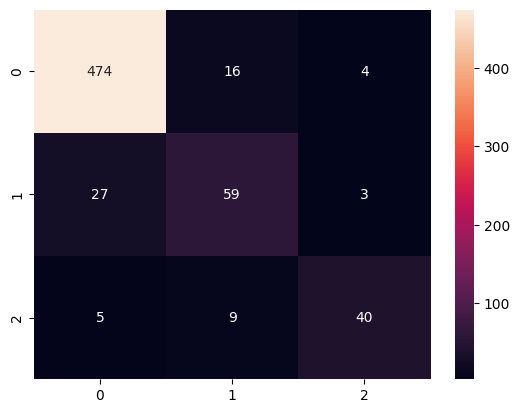

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_1_train = modelo_1_final.predict(X_train)

print("metricas de desempeño en entrenamiento")
print(classification_report(Y_train, y_pred_1_train))
sb.heatmap(confusion_matrix(Y_train, y_pred_1_train), annot=True, fmt='d')

plt.show()

metricas de desempeño en validacion
              precision    recall  f1-score   support

         1.0       0.93      0.96      0.95      1161
         2.0       0.66      0.65      0.65       206
         3.0       0.82      0.65      0.72       122

    accuracy                           0.89      1489
   macro avg       0.81      0.75      0.77      1489
weighted avg       0.89      0.89      0.89      1489



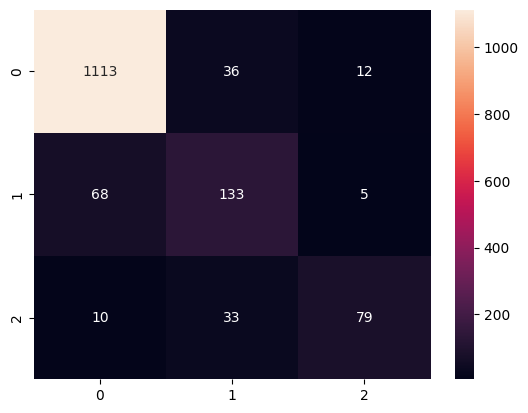

In [ ]:
y_pred_test_1 = modelo_1_final.predict(X_test)
print("metricas de desempeño en validacion")

print(classification_report(Y_test, y_pred_test_1))
sb.heatmap(confusion_matrix(Y_test, y_pred_test_1), annot=True, fmt='d')

plt.show()


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
modelo_2 = KNeighborsClassifier()

param_grid = {'n_neighbors': [3, 5, 7, 19,21,53],'p': [1, 2]
}

clf_2=GridSearchCV(estimator=modelo_2,
                   param_grid=param_grid, cv=5, scoring='f1_weighted')


clf_2.fit(X_train, Y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...], 'p': [1, 2]}"
,scoring,'f1_weighted'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,7


In [ ]:
validation = pd.concat([
    pd.DataFrame(clf_2.cv_results_['params']),
    pd.DataFrame(clf_2.cv_results_['mean_test_score'], columns=['f1'])
], axis=1)

validation = validation.sort_values(by='f1', ascending=False)



validation

,n_neighbors,p,f1
4,7,1,0.897228
0,3,1,0.891503
1,3,2,0.887129
2,5,1,0.885700
3,5,2,0.872322
5,7,2,0.868014
6,19,1,0.865301
8,21,1,0.858859
7,19,2,0.844135
9,21,2,0.837227


In [ ]:
modelo_2_final = clf_2.best_estimator_
modelo_2_final

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


metricas de desempeño en entrenamiento
              precision    recall  f1-score   support

         1.0       0.94      0.98      0.96       494
         2.0       0.76      0.69      0.72        89
         3.0       0.90      0.70      0.79        54

    accuracy                           0.91       637
   macro avg       0.87      0.79      0.82       637
weighted avg       0.91      0.91      0.91       637



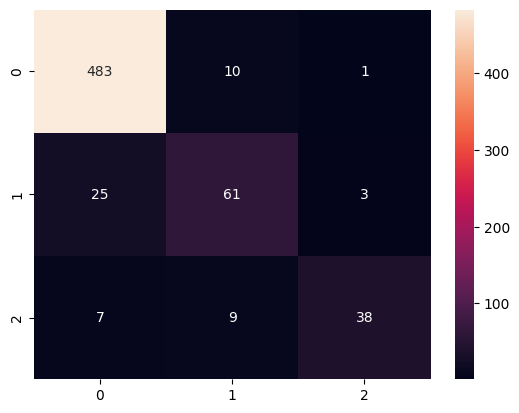

In [ ]:
y_pred_2_train = modelo_2_final.predict(X_train)

print("metricas de desempeño en entrenamiento")
print(classification_report(Y_train, y_pred_2_train))
sb.heatmap(confusion_matrix(Y_train, y_pred_2_train), annot=True, fmt='d')

plt.show()

metricas de desempeño en validacion
              precision    recall  f1-score   support

         1.0       0.92      0.95      0.93      1161
         2.0       0.66      0.60      0.63       206
         3.0       0.89      0.66      0.75       122

    accuracy                           0.88      1489
   macro avg       0.82      0.74      0.77      1489
weighted avg       0.88      0.88      0.88      1489



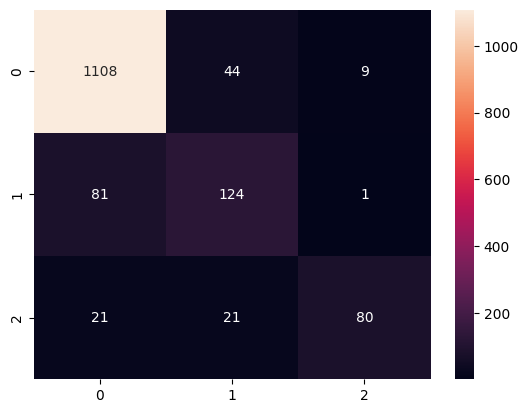

In [ ]:
y_pred_test_2= modelo_2_final.predict(X_test)
print("metricas de desempeño en validacion")

print(classification_report(Y_test, y_pred_test_2))
sb.heatmap(confusion_matrix(Y_test, y_pred_test_2), annot=True, fmt='d')

plt.show()
